In [20]:
!pip install dlib scipy opencv-python
!wget https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bunzip2 -f shape_predictor_68_face_landmarks.dat.bz2

--2026-02-25 09:03:27--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2.3’

shape_predictor_68_ 100%[===================>]  61.07M  13.9MB/s    in 5.0s    

2026-02-25 09:03:33 (12.1 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2.3’ saved [64040097/64040097]



In [8]:
!pip install dlib imutils scipy opencv-python

In [9]:
!wget https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bunzip2 shape_predictor_68_face_landmarks.dat.bz2

--2026-02-25 08:43:09--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2.2’

shape_predictor_68_ 100%[===================>]  61.07M  12.5MB/s    in 5.9s    

2026-02-25 08:43:16 (10.3 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2.2’ saved [64040097/64040097]

bunzip2: Output file shape_predictor_68_face_landmarks.dat already exists.


1 → Upload Image
2 → Live Camera
Enter choice: 1


Saving your_face_image.jpeg to your_face_image (4).jpeg
EAR: 0.27 MAR: 0.008


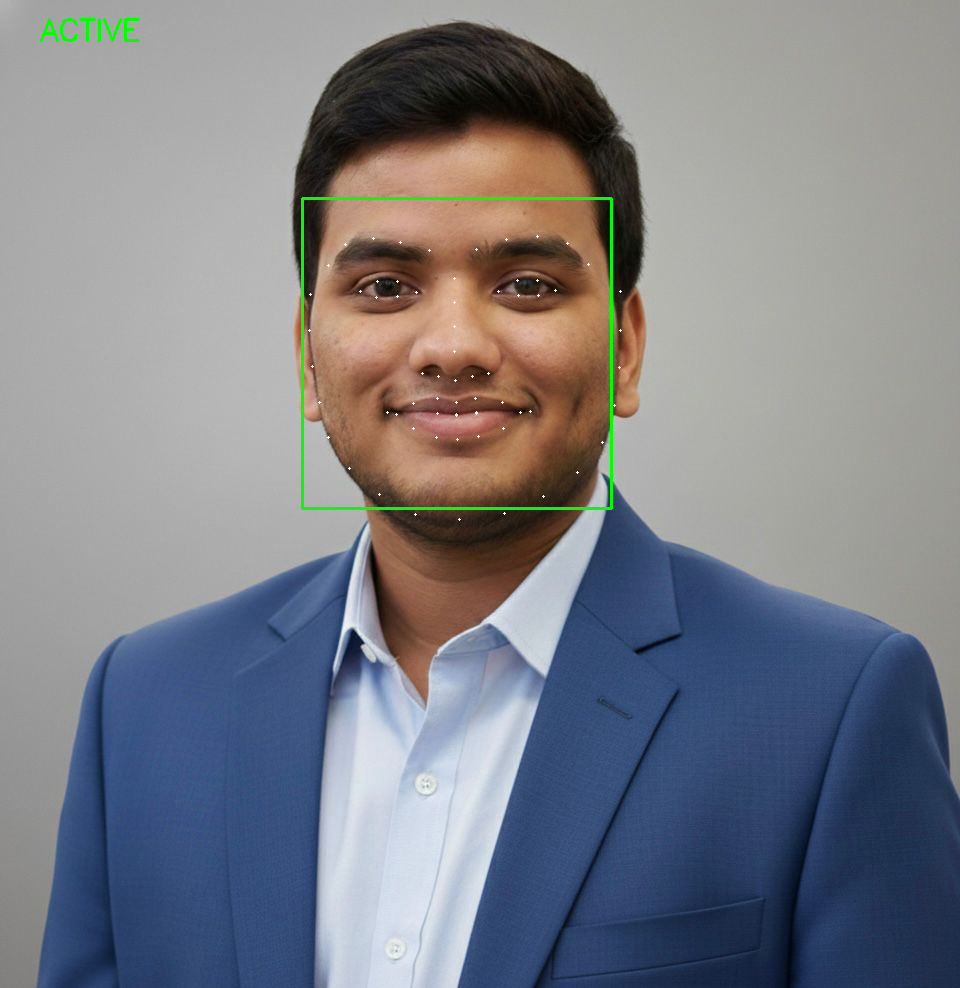

In [33]:
import dlib
import cv2
import numpy as np
from scipy.spatial import distance
from google.colab.patches import cv2_imshow
from google.colab import files
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

# ---------- EAR ----------
def compute_EAR(vec):
    a = distance.euclidean(vec[1], vec[5])
    b = distance.euclidean(vec[2], vec[4])
    c = distance.euclidean(vec[0], vec[3])
    return (a + b) / (2.0 * c)

# ---------- MAR ----------
def compute_MAR(vec):
    a = distance.euclidean(vec[62], vec[66])
    b = distance.euclidean(vec[63], vec[65])
    c = distance.euclidean(vec[60], vec[64])
    return (a + b) / (2.0 * c)

# Load models
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

print("1 → Upload Image")
print("2 → Live Camera")
choice = input("Enter choice: ")

# ---------- IMAGE MODE ----------
if choice == "1":
    uploaded = files.upload()
    image_path = list(uploaded.keys())[0]
    img = cv2.imread(image_path)

# ---------- CAMERA MODE ----------
elif choice == "2":

    display(Javascript('''
    async function takePhoto() {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();
      document.body.appendChild(div);
      div.appendChild(video);

      await new Promise(resolve => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video,0,0);
      stream.getTracks().forEach(track => track.stop());
      div.remove();
      return canvas.toDataURL('image/jpeg');
    }
    '''))

    data = eval_js("takePhoto()")
    binary = b64decode(data.split(',')[1])
    img = cv2.imdecode(np.frombuffer(binary,np.uint8),cv2.IMREAD_COLOR)

else:
    print("Invalid choice")
    exit()

if img is None:
    print("Image not loaded")
    exit()

# ---------- PROCESS ----------
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = detector(gray)

vec = np.empty([68,2],dtype=int)

for face in faces:

    shape = predictor(gray, face)

    for i in range(68):
        vec[i][0]=shape.part(i).x
        vec[i][1]=shape.part(i).y
        cv2.circle(img,(vec[i][0],vec[i][1]),1,(255,255,255),-1)

    right_ear = compute_EAR(vec[42:48])
    left_ear = compute_EAR(vec[36:42])
    avg_ear = (right_ear + left_ear)/2
    mar = compute_MAR(vec)

    print("EAR:",round(avg_ear,3),"MAR:",round(mar,3))

    # ---- FINAL STATUS LOGIC ----
    if mar > 0.65:
        status="YAWNING"
        color=(255,0,0)

    elif avg_ear < 0.20:
        status="SLEEPY"
        color=(0,0,255)

    elif avg_ear < 0.24:
        status="DROWSY"
        color=(0,255,255)

    else:
        status="ACTIVE"
        color=(0,255,0)

    x1,y1,x2,y2 = face.left(),face.top(),face.right(),face.bottom()

    cv2.rectangle(img,(x1,y1),(x2,y2),color,2)
    cv2.putText(img,status,(40,40),
                cv2.FONT_HERSHEY_SIMPLEX,1,color,2)

cv2_imshow(img)